# Car Price Prediction: A Regression Analysis Project

This project explores how far classical linear models can go in predicting used car prices from tabular features. I wanted to use it as a hands-on exercise in the full regression workflow: exploratory data analysis, feature cleaning, visualization, baseline linear regression, regularized variants (Lasso, Ridge, ElasticNet), categorical encoding, and some feature engineering experiments, finishing with a business-oriented evaluation metric.

**Dataset:** used car listings (train/test split), with features such as year, mileage, engine specs, fuel type, seller type, transmission, and ownership history, and `selling_price` as the target.

**Goals of this project:**
- Clean and understand a messy real-world tabular dataset
- Visualize feature distributions and relationships with the target
- Build and compare linear regression, Lasso, Ridge, and ElasticNet models
- Add categorical features via one-hot encoding
- Experiment with feature engineering ideas
- Evaluate the model with a practical, business-relevant metric (% of predictions within 10% of the true price)


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

random.seed(42)
np.random.seed(42)

**Why fix random seeds?**

Fixing the random seed makes any step that involves randomness (splitting data, initializing models, etc.) reproducible — every run produces the same numbers, which makes results comparable and debugging easier.

In [2]:
print("Fixing seeds ensures that every run produces the same random outcomes, making results reproducible.")

Fixing seeds ensures that every run produces the same random outcomes, making results reproducible.


## Part 1 | Exploratory Data Analysis

### Basic EDA and feature cleaning

In [3]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


Take a look at 10 **random** rows of the training set.

In [4]:
df_train.sample(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
6565,Renault KWID Climber 1.0 MT BSIV,2019,300000,35000,Petrol,Individual,Manual,First Owner,23.01 kmpl,999 CC,67 bhp,91Nm@ 4250rpm,5.0
2943,Maruti Wagon R LXI,2013,225000,58343,Petrol,Trustmark Dealer,Manual,First Owner,21.79 kmpl,998 CC,67.05 bhp,90Nm@ 3500rpm,5.0
2024,Hyundai i20 Asta 1.2,2013,360000,30000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
263,Hyundai i20 1.2 Asta,2010,300000,70000,Petrol,Individual,Manual,First Owner,17.0 kmpl,1197 CC,80 bhp,"11.4 kgm at 4,000 rpm",5.0
4586,Skoda Octavia L and K 1.9 TDI MT,2005,250000,120000,Diesel,Individual,Manual,Third Owner,16.4 kmpl,1896 CC,90 bhp,"21.4@ 1,900(kgm@ rpm)",5.0
4479,Maruti Ciaz ZXi,2016,700000,20000,Petrol,Individual,Manual,First Owner,20.73 kmpl,1373 CC,91.1 bhp,130Nm@ 4000rpm,5.0
4881,Hyundai Grand i10 1.2 Kappa Magna BSIV,2017,445000,27000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
3583,Ford Ecosport 1.5 DV5 MT Trend,2016,515000,68609,Diesel,Dealer,Manual,First Owner,22.7 kmpl,1498 CC,89.84 bhp,204Nm@ 2000-2750rpm,5.0
6361,Hyundai Verna 1.4 VTVT,2014,500000,33400,Petrol,Individual,Manual,First Owner,17.43 kmpl,1396 CC,105.5 bhp,135.3Nm@ 5000rpm,5.0
4108,Hyundai i20 Era 1.2,2015,490000,45900,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0


Look at the first 5 and last 5 rows of the test set.

In [5]:
df_test.head(5)
df_test.tail(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
995,Hyundai i10 Magna 1.1L,2008,250000,100000,Petrol,Individual,Manual,Second Owner,19.81 kmpl,1086 CC,68.05 bhp,99.04Nm@ 4500rpm,5.0
996,Hyundai i20 2015-2017 Sportz 1.2,2017,440000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0
997,Hyundai i20 Era Diesel,2009,340000,40000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
998,Hyundai i10 Asta,2012,350000,25000,Petrol,Individual,Manual,First Owner,20.36 kmpl,1197 CC,78.9 bhp,111.8Nm@ 4000rpm,5.0
999,Honda City i DTec SV,2016,700000,110000,Diesel,Individual,Manual,First Owner,26.0 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0


Compute basic statistics for both numeric and categorical columns, for train and test.

In [6]:
df_train.describe(include='object')
df_test.describe(include='object')

/tmp/ipykernel_132/441619325.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.describe(include='object')
/tmp/ipykernel_132/441619325.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,1000,1000,1000,1000,1000,981,981,981,981
unique,621,4,3,2,5,237,88,182,226
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner,18.6 kmpl,1248 CC,74 bhp,200Nm@ 1750rpm
freq,15,534,837,877,623,23,116,43,57


Check for missing values, and if there are any, see which columns they're in.

In [7]:
df_train.isna().sum()
df_test.isna().sum()

name              0
year              0
selling_price     0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage          19
engine           19
max_power        19
torque           19
seats            19
dtype: int64

Check whether the training set contains duplicate rows (identical features, target excluded), and if so, how many.

In [8]:
df_train.drop(columns=['fuel', 'seller_type', 'transmission', 'owner'])
df_train.duplicated().sum()

np.int64(985)

Display the duplicated rows.

In [9]:
df_train[df_train.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
254,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
258,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
324,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
325,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
326,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6880,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37 kmpl,1461 CC,108.45 bhp,240Nm@ 1750rpm,5.0
6881,Maruti Ciaz Alpha Diesel,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09 kmpl,1248 CC,88.50 bhp,200Nm@ 1750rpm,5.0
6989,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
6997,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


Drop duplicate rows. When the same feature description maps to different prices, keep the first occurrence.

In [10]:
df_train = df_train.drop_duplicates()

In [11]:
df_train.shape

(6014, 13)

Reset the row index so it runs cleanly from 0 with no gaps.

In [12]:
df_train.reset_index(drop=True, inplace=True)

The `mileage`, `engine`, `max_power`, and `torque` columns are messy (units embedded as text). Let's fix them:
- strip the units from `mileage`, `engine`, `max_power`
- cast those columns to `float`
- split `torque` into two numeric columns: `torque` value and `max_torque_rpm` (rather than dropping it), handling the fact that the two use different units

All of this needs to be applied to both the train and test sets.

In [13]:
df_train = df_train.astype({
    "mileage": str,
    "engine": str,
    "max_power": str,
    "torque": str
})

df_test = df_test.astype({
    "mileage": str,
    "engine": str,
    "max_power": str,
    "torque": str
})

In [14]:
for col in ['mileage', 'engine', 'max_power']:
    df_train[col] = df_train[col].str.extract(r'(\d+\.?\d*)').astype(float)

df_train['torque_val'] = df_train['torque'].str.extract(r'(\d+\.?\d*)').astype(float)
df_train['max_torque_rpm'] = df_train['torque'].str.extract(r'@ *(\d+)').astype(float)

df_train = df_train.drop(columns=['torque'])
for col in ['mileage', 'engine', 'max_power']:
    df_test[col] = df_test[col].str.extract(r'(\d+\.?\d*)').astype(float)

df_test['torque_val'] = df_test['torque'].str.extract(r'(\d+\.?\d*)').astype(float)
df_test['max_torque_rpm'] = df_test['torque'].str.extract(r'@ *(\d+)').astype(float)

df_test = df_test.drop(columns=['torque'])

Fill missing values with medians and confirm none remain.

Note: the correct approach is to compute the median on the training set and use that same value to fill gaps in the test set (the same applies to standardizing features later).

In [15]:
df_train.fillna(df_train.median(numeric_only=True), inplace=True)
df_test.fillna(df_train.median(numeric_only=True), inplace=True)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_val,max_torque_rpm
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.00,2498.0,112.00,7.0,260.00,2000.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.50,1497.0,108.50,5.0,260.00,1500.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.90,1799.0,130.00,5.0,172.00,4300.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.10,1498.0,98.60,5.0,200.00,1750.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.50,1172.0,65.00,5.0,96.00,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Hyundai i10 Magna 1.1L,2008,250000,100000,Petrol,Individual,Manual,Second Owner,19.81,1086.0,68.05,5.0,99.04,4500.0
996,Hyundai i20 2015-2017 Sportz 1.2,2017,440000,50000,Petrol,Individual,Manual,Second Owner,18.60,1197.0,81.83,5.0,114.70,4000.0
997,Hyundai i20 Era Diesel,2009,340000,40000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,22.40,2000.0
998,Hyundai i10 Asta,2012,350000,25000,Petrol,Individual,Manual,First Owner,20.36,1197.0,78.90,5.0,111.80,4000.0


Now that there are no missing values left, convert columns to more appropriate types (`engine` and `seats` to `int`).

**Why might `seats` be better treated as a categorical variable rather than an integer** (even though we don't do that here)? Because the number of seats behaves more like a car "type" label than a continuous quantity — operations like taking a median or an average don't really make sense for it.

In [16]:
print("Seat count behaves like a categorical car-type label rather than a continuous quantity, so taking a median/mean of it is not really meaningful.")

Seat count behaves like a categorical car-type label rather than a continuous quantity, so taking a median/mean of it is not really meaningful.


In [17]:
df_train = df_train.astype({
    "engine": "int",
    "seats": "int"
})
df_test = df_test.astype({
    "engine": "int",
    "seats": "int"
})

### Visualizations

There isn't a huge amount to visualize here, but it's worth (1) seeing how the features are distributed, (2) understanding how correlated the features are with each other and with the target, and (3) checking whether the test set looks like it's distributed differently from the train set.

Pairwise distributions of all numeric features in the training set.

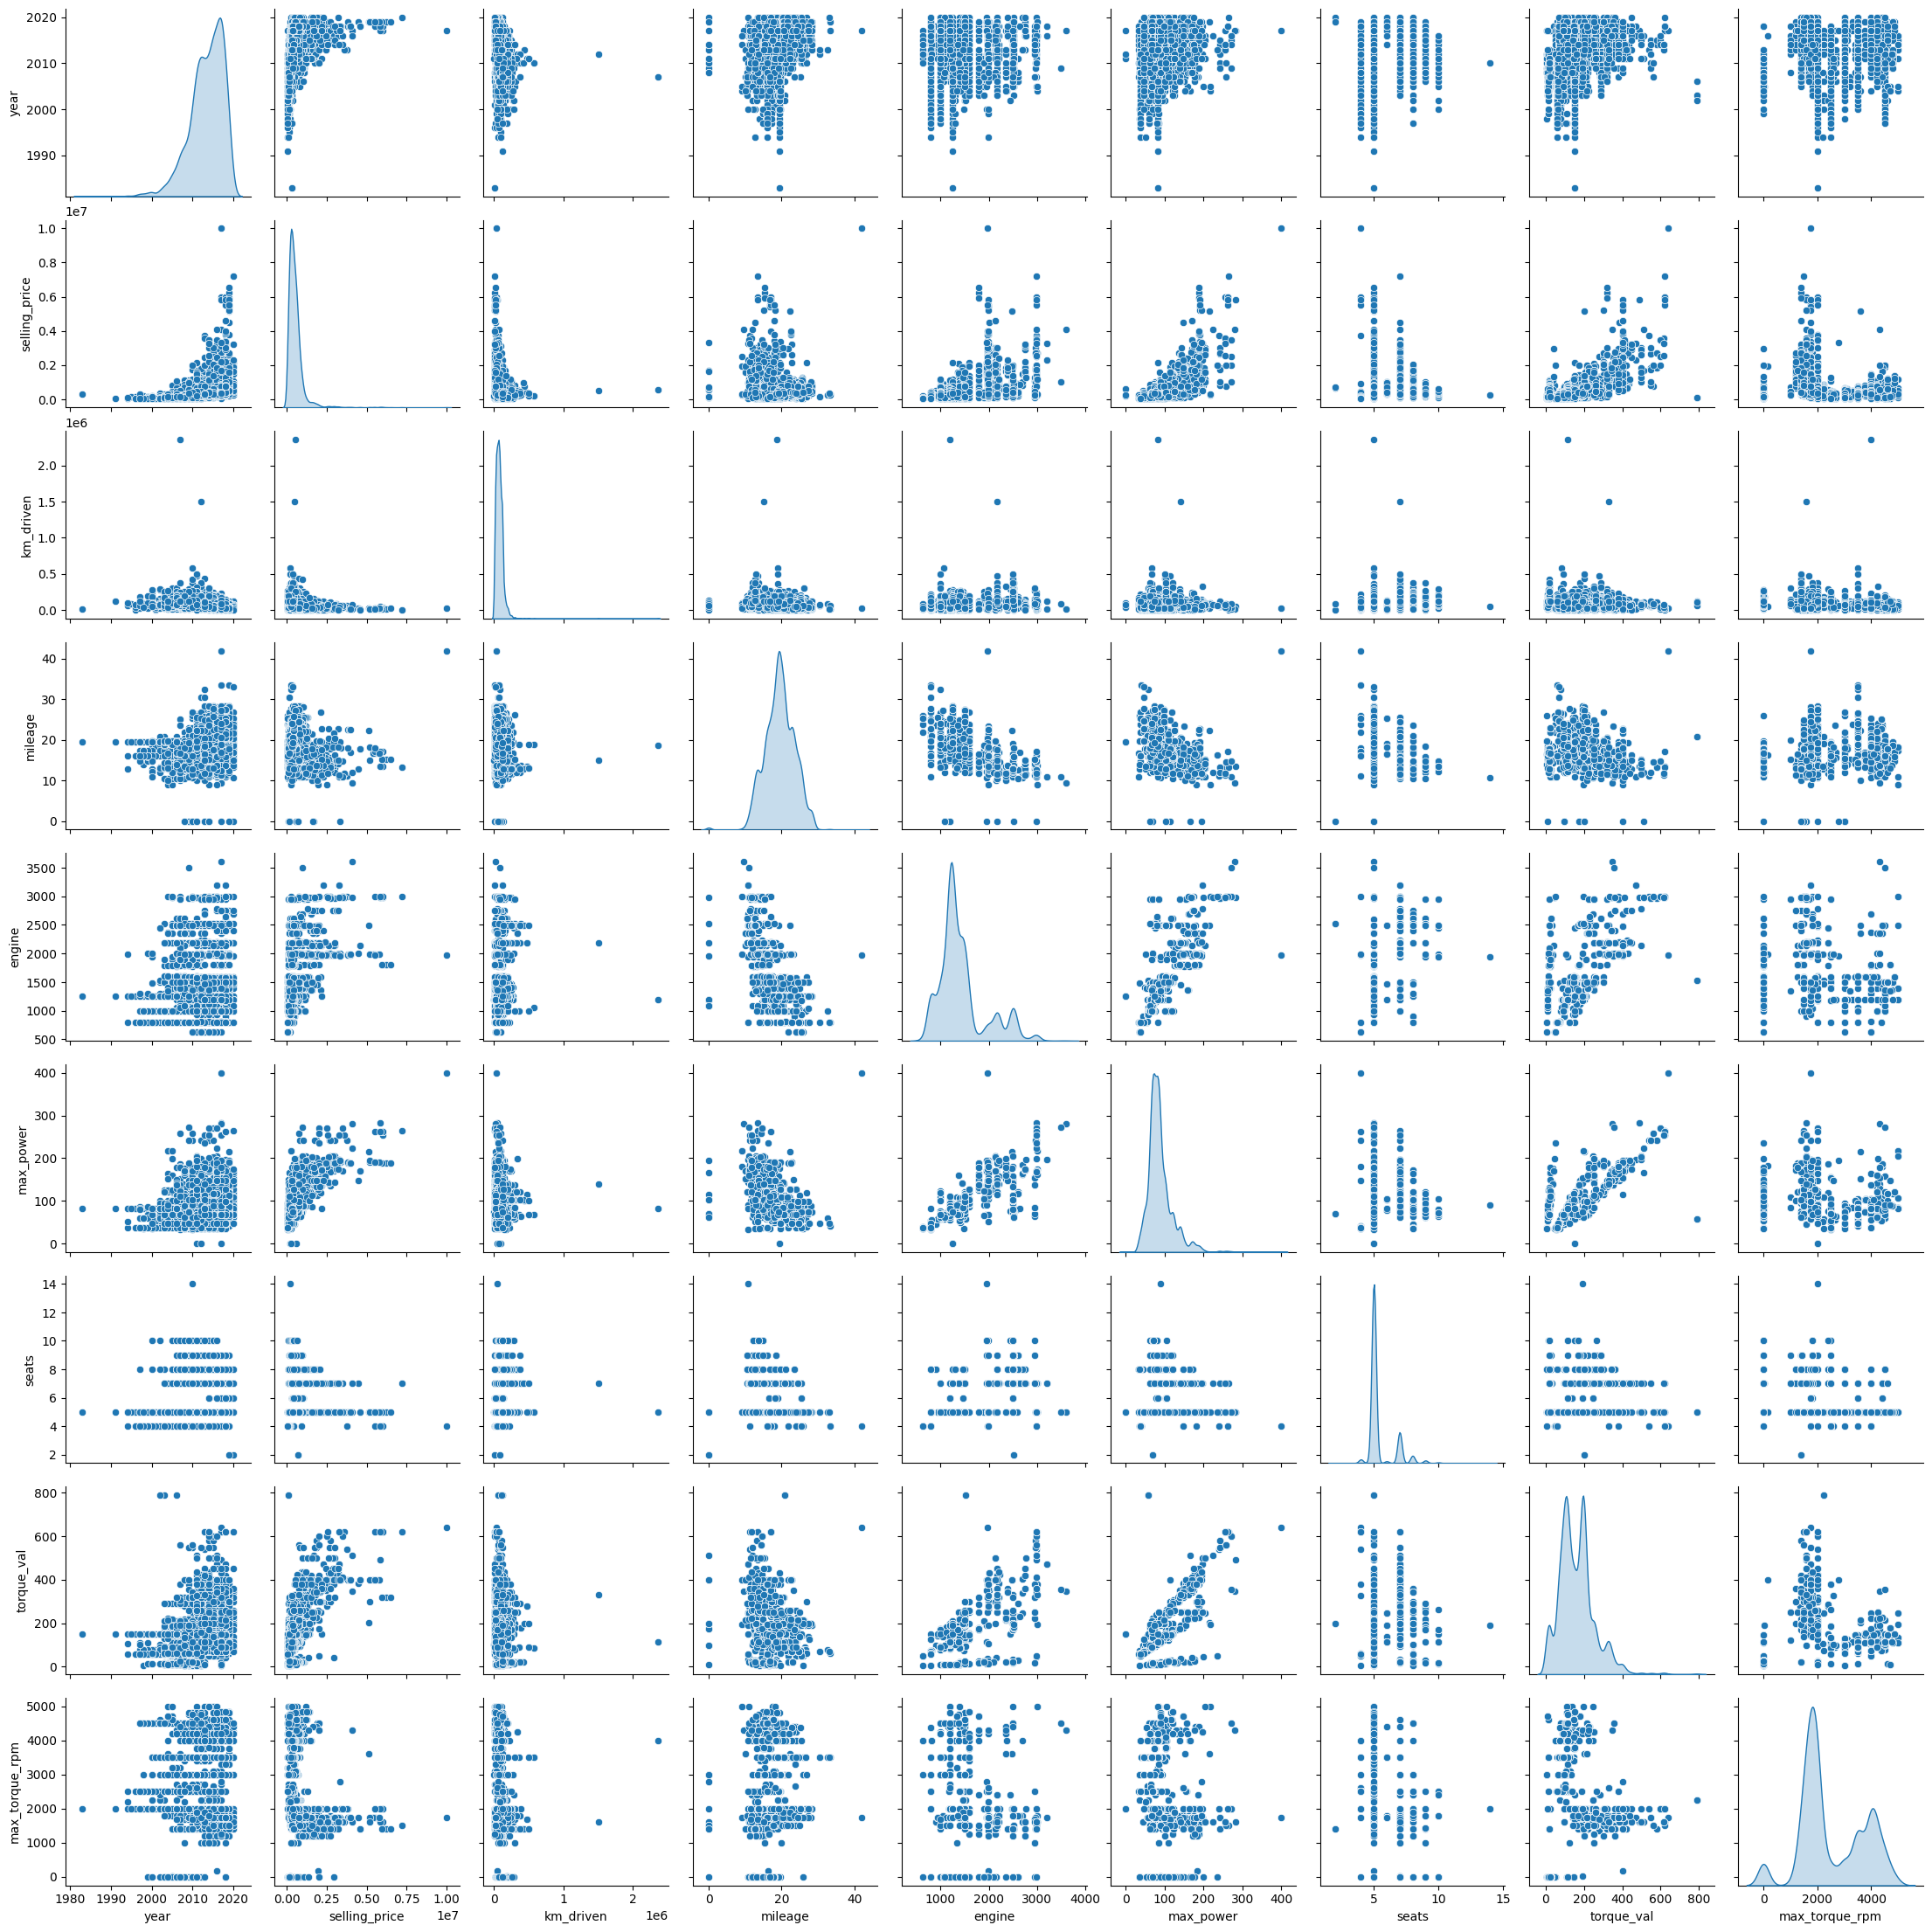

In [18]:
numeric_cols = df_train.select_dtypes(include="number").columns
sns.pairplot(df_train[numeric_cols], diag_kind="kde")
plt.show()

This plot isn't as informative as looking at each feature individually, but it does let us draw some conclusions (even if intuition alone would get us most of the way there):

- **Relationship with the target:** features like `year`, `max_power`, and `engine` show a visible relationship with `selling_price` — newer cars with more power/engine size tend to sell for more, while `km_driven` trends negatively with price.
- **Feature correlations:** `engine`, `max_power`, and `torque_val` are noticeably correlated with each other, which makes sense since they all relate to the vehicle's power characteristics.

Pairplot for the test data — do the train and test populations look similar?

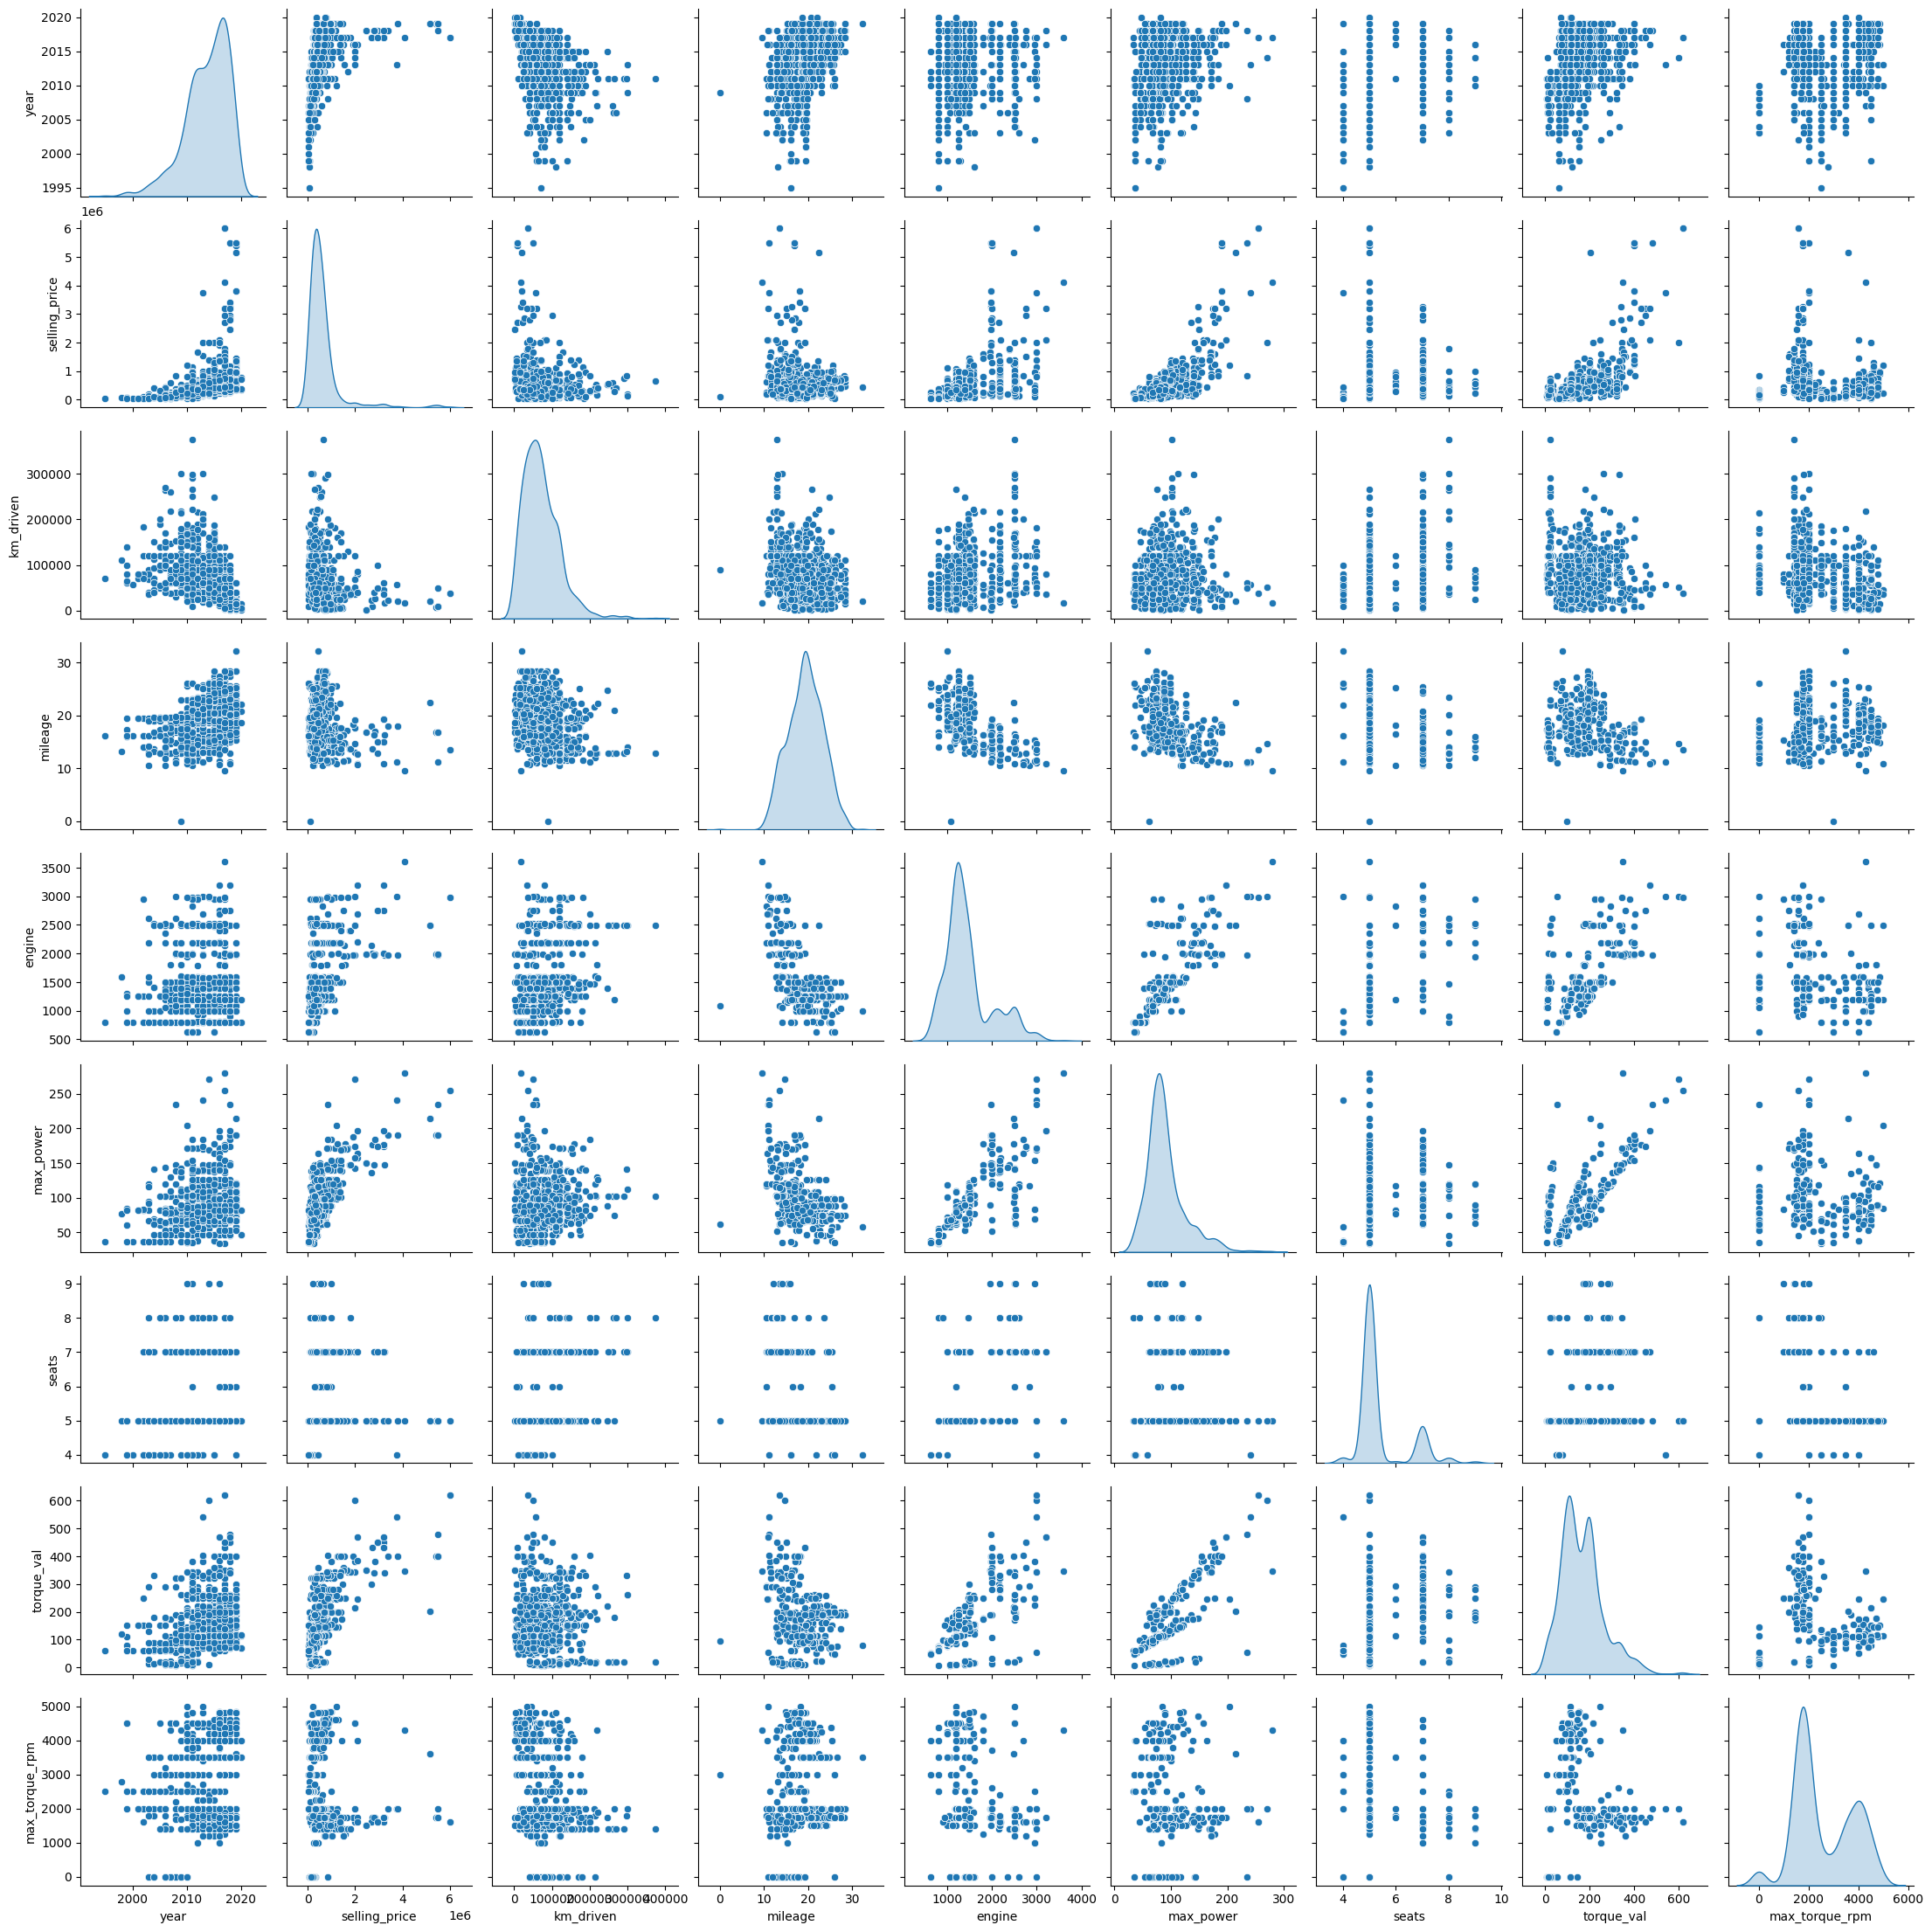

The train and test distributions look similar.


In [19]:
sns.pairplot(df_test[numeric_cols], diag_kind='kde')
plt.show()
print("The train and test distributions look similar.")

Heatmap of pairwise correlations between numeric columns in the training set.

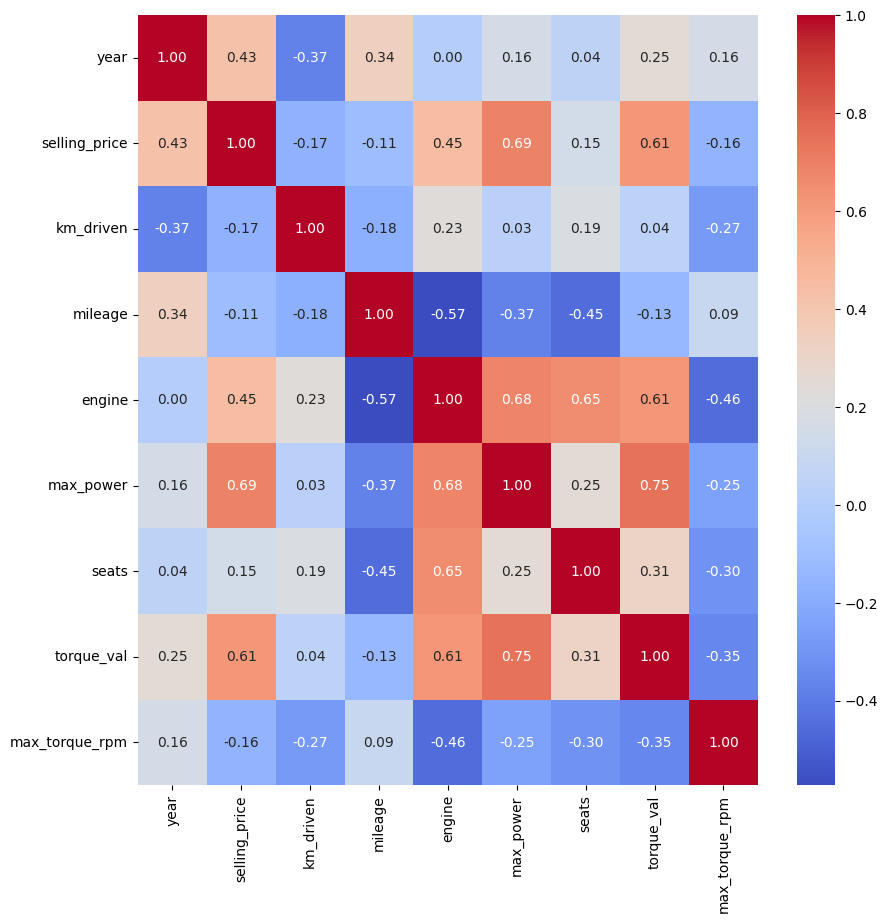

In [20]:
plt.figure(figsize=(10,10))
sns.heatmap(df_train[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

**Questions from the correlation heatmap:**
- Which two features are the least correlated with each other? `year` and `engine`, `year` and `seats`.
- Which pair shows a fairly strong positive linear relationship? `max_power` and `torque_val`.
- Is it fair to say, based on the data, that the older the car, the more kilometers it has likely driven by the time it's sold? Yes.

In [21]:
print("1) year and engine, year and seats \n2) max_power, torque_val \n3) yes")

1) year and engine, year and seats 
2) max_power, torque_val 
3) yes


Scatter plot for the most correlated pair of features (in the training set).

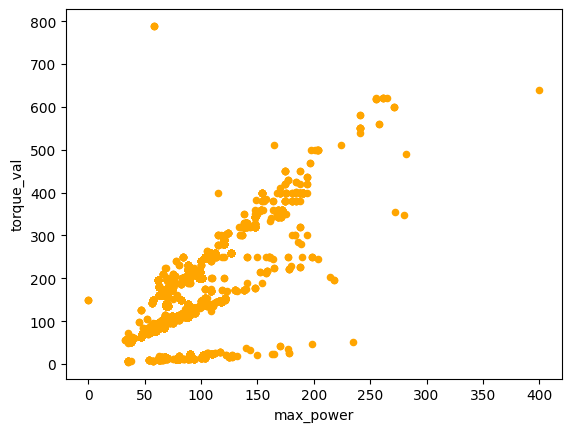

In [22]:
df_train.plot.scatter(x='max_power', y='torque_val', c='orange')
plt.show()

## Part 2 | Model on numeric features only

Build `y_train`/`y_test` from `selling_price`, and drop `selling_price` plus all categorical columns (everything except `seats`) from the feature matrices.

In [23]:
y_train = df_train['selling_price']
X_train = df_train.select_dtypes(include=['number']).drop(columns=['selling_price'])

In [24]:
X_train.head()

,year,km_driven,mileage,engine,max_power,seats,torque_val,max_torque_rpm
0,2014,145500,23.40,1248,74.00,5,190.00,2000.0
1,2014,120000,21.14,1498,103.52,5,250.00,1500.0
2,2010,127000,23.00,1396,90.00,5,22.40,2000.0
3,2007,120000,16.10,1298,88.20,5,11.50,4.0
4,2017,45000,20.14,1197,81.86,5,113.75,4000.0


In [25]:
y_test = df_test['selling_price']
X_test = df_test.select_dtypes(include=['number']).drop(columns=['selling_price'])

Train a plain linear regression with default parameters, and report $R^2$ and MSE for both train and test.

From here on I'll report both metrics on train and test for every model I fit, so it's clear how each experiment is actually performing.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE
from sklearn.model_selection import train_test_split

model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = MSE(y_train, y_train_pred)
mse_test = MSE(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train: R² = {r2_train:.4f}, MSE = {mse_train:.4f}")
print(f"Test : R² = {r2_test:.4f}, MSE = {mse_test:.4f}")

Train: R² = 0.5989, MSE = 114293598823.9266
Test : R² = 0.5986, MSE = 230720782305.3454


**Rule of thumb:** if you're using a linear model, standardize the features. Let's apply that here.

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Not a huge improvement in itself, but now the model is directly interpretable — with standardized features, the coefficient magnitudes tell us which feature is most informative for predicting price. Looking at the fitted coefficients, `max_power` stands out as the most influential feature.

In [28]:
coefs = pd.Series(model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
coefs

year              38690.379549
seats            -32766.236575
max_power          8865.140875
mileage           -1474.367980
torque_val          732.692224
engine               42.223046
max_torque_rpm      -27.316795
km_driven            -0.815597
dtype: float64

Now let's try Lasso regression. From here on, models are trained on the standardized features.

In [29]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lasso = Pipeline([
    ("model", Lasso(random_state=42))
])

lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

print(f"Lasso: R² = {r2_score(y_test, y_pred):.4f}, MSE = {MSE(y_test, y_pred):.4f}")

Lasso: R² = 0.5986, MSE = 230720954023.0989


**Did L1 regularization with default parameters zero out any weights? Why (or why not)?**

In [30]:
lasso_coefs = pd.Series(lasso.named_steps["model"].coef_, index=X_train.columns)
print(lasso_coefs)
print("Number of zeroed coefficients:", (lasso_coefs == 0).sum())

year              38690.120015
km_driven            -0.815601
mileage           -1474.026977
engine               42.220547
max_power          8865.180528
seats            -32763.746060
torque_val          732.687963
max_torque_rpm      -27.316509
dtype: float64
Number of zeroed coefficients: 0


Grid search (10-fold CV) over regularization strength for Lasso.

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {"model__alpha": np.logspace(-3, 2, 50)}

grid_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Best alpha for Lasso:", grid_lasso.best_params_)
print("Best R² (train, CV):", grid_lasso.best_score_)
print("R² (test):", r2_score(y_test, grid_lasso.predict(X_test)))

Best alpha for Lasso: {'model__alpha': np.float64(0.001)}
Best R² (train, CV): 0.5758985335194222
R² (test): 0.5986267901726701


**How many models did the grid search have to fit?** 50 alpha values × 10 folds = 500 model fits.

**What's the regularization coefficient of the best model, and did any weights get zeroed out at that strength?**

In [32]:
best_lasso = grid_lasso.best_estimator_.named_steps["model"]
best_lasso_coefs = pd.Series(best_lasso.coef_, index=X_train.columns)
print(best_lasso_coefs)
print("Number of zeroed coefficients:", (best_lasso_coefs == 0).sum())

year              38690.379289
km_driven            -0.815597
mileage           -1474.367639
engine               42.223043
max_power          8865.140915
seats            -32766.234084
torque_val          732.692220
max_torque_rpm      -27.316795
dtype: float64
Number of zeroed coefficients: 0


Grid search (10-fold CV) over ElasticNet hyperparameters.

In [33]:
from sklearn.linear_model import ElasticNet

elastic = Pipeline([
    ("model", ElasticNet(random_state=42))
])

param_grid = {
    "model__alpha": np.logspace(-3, 2, 20),
    "model__l1_ratio": np.linspace(0, 1, 10)
}
grid_elastic = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

grid_elastic.fit(X_train, y_train)

print("Best ElasticNet parameters:", grid_elastic.best_params_)
print("Best R² (train, CV):", grid_elastic.best_score_)
print("R² (test):", r2_score(y_test, grid_elastic.predict(X_test)))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.502e+14, tolerance: 1.262e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.212e+14, tolerance: 1.596e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instea

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.502e+14, tolerance: 1.262e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.212e+14, tolerance: 1.596e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instea

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.089e+14, tolerance: 1.546e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.502e+14, tolerance: 1.262e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.212e+14, tolerance: 1.596e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instea

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.502e+14, tolerance: 1.262e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.212e+14, tolerance: 1.596e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instea

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.904e+14, tolerance: 1.262e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.616e+14, tolerance: 1.596e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instea

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.992e+14, tolerance: 1.262e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.718e+14, tolerance: 1.596e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instea

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.083e+14, tolerance: 1.262e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.832e+14, tolerance: 1.596e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instea

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.721e+14, tolerance: 1.546e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Best ElasticNet parameters: {'model__alpha': np.float64(0.001), 'model__l1_ratio': np.float64(1.0)}
Best R² (train, CV): 0.5758985335194222
R² (test): 0.5986267901726701


**Which hyperparameters gave the best model?**

In [34]:
print(grid_elastic.best_params_)

{'model__alpha': np.float64(0.001), 'model__l1_ratio': np.float64(1.0)}


At this point regularization alone isn't buying much more, so let's move on to the next part.

## Part 3 | Adding categorical features

Drop the target and the car name column from `df_train`.

In [35]:
X_train_cat = df_train.drop(columns=['selling_price', 'name'])
X_train_cat.describe(include='object')

/tmp/ipykernel_132/887173694.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train_cat.describe(include='object')


,fuel,seller_type,transmission,owner
count,6014,6014,6014,6014
unique,4,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,3269,5394,5505,3721


One-hot encode the categorical features and `seats`.

To avoid multicollinearity, drop one of the resulting columns for each encoded feature.

In [36]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df_train[["seats"]])
X_encoded = np.hstack([df_train.drop(columns=["seats"]).values, encoded])

### Extra visualizations

A couple of additional plots I found useful beyond what's above: actual vs. predicted price for both train and test, to see how well-calibrated the baseline model's predictions are.

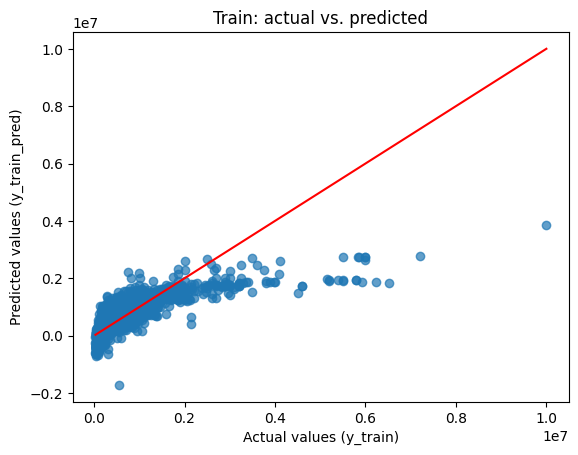

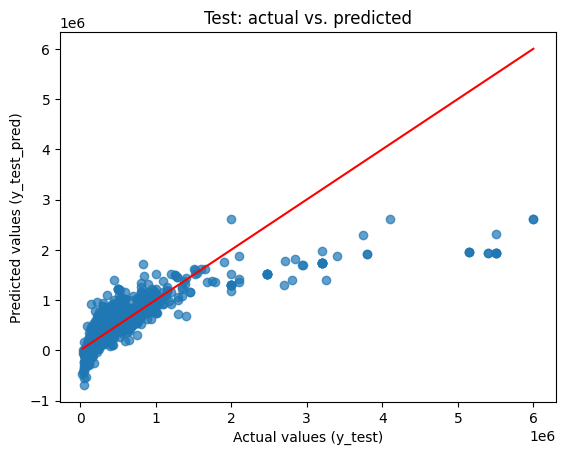

In [37]:
plt.scatter(y_train, y_train_pred, alpha=0.7)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color="red")
plt.xlabel("Actual values (y_train)")
plt.ylabel("Predicted values (y_train_pred)")
plt.title("Train: actual vs. predicted")
plt.show()

plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual values (y_test)")
plt.ylabel("Predicted values (y_test_pred)")
plt.title("Test: actual vs. predicted")
plt.show()

Grid search over the regularization parameter `alpha` for Ridge regression, scoring by $R^2$, 10-fold CV.

**Did this improve prediction quality?**

In [38]:
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer

ridge = Pipeline([
    ("model", Ridge(random_state=42))
])

param_grid = {"model__alpha": np.logspace(-3, 2, 50)}

grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Best alpha for Ridge:", grid_ridge.best_params_)
print("Best R² (train, CV):", grid_ridge.best_score_)
print("R² (test):", r2_score(y_test, grid_ridge.predict(X_test)))

Best alpha for Ridge: {'model__alpha': np.float64(0.001)}
Best R² (train, CV): 0.5758985332174789
R² (test): 0.5986267889041774


## Part 4 (bonus) | Feature engineering

Some ideas I tried out here, restricted to linear/polynomial regression only:

1. **New features from existing ones** — ratios/products of existing features (e.g. horsepower per liter of engine volume), and non-linear transforms suggested by the EDA plots (e.g. price vs. year looked more quadratic than linear, so a squared year term might help).
2. **New information from existing columns** — e.g. thresholded indicators like "third owner or more", or combined rules like "first/second owner and sold by an official dealer".
3. **Revisiting earlier choices** — median imputation isn't necessarily optimal (adding a "was missing" dummy column can help); outliers weren't handled (boxplots are a simple way to spot them); the target itself might benefit from a log transform if it's skewed.

Below is a small demonstration of these ideas on a toy example.

In [39]:
import datetime
df = pd.DataFrame({
    "year": [2010, 2015, 2018, 2020, 2012],
    "mileage": [150000, 80000, 50000, 20000, 120000],
    "engine_power": [120, 150, 200, 250, 100],
    "engine_volume": [1.6, 2.0, 2.5, 3.0, 1.4],
    "owner": [2, 1, 1, 2, 3],
    "price": [400000, 700000, 900000, 1200000, 350000]
})
df["power_per_litre"] = df["engine_power"] / df["engine_volume"]
current_year = datetime.datetime.now().year
df["car_age"] = current_year - df["year"]
df["mileage_per_year"] = df["mileage"] / df["car_age"]
df["year_squared"] = df["year"]**2
df["owner_3plus"] = (df["owner"] >= 3).astype(int)
df["is_new"] = (df["car_age"] < 3).astype(int)
df["engine_volume_filled"] = df["engine_volume"].fillna(df["engine_volume"].median())
df["engine_volume_missing"] = df["engine_volume"].isna().astype(int)
for col in ["mileage", "engine_power", "price"]:
    low, high = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(low, high)
df["log_price"] = np.log1p(df["price"])
df

,year,mileage,engine_power,engine_volume,owner,price,power_per_litre,car_age,mileage_per_year,year_squared,owner_3plus,is_new,engine_volume_filled,engine_volume_missing,log_price
0,2010,148800,120.0,1.6,2,400000,75.000000,16,9375.000000,4040100,0,0,1.6,0,12.899222
1,2015,80000,150.0,2.0,1,700000,75.000000,11,7272.727273,4060225,0,0,2.0,0,13.458837
2,2018,50000,200.0,2.5,1,900000,80.000000,8,6250.000000,4072324,0,0,2.5,0,13.710151
3,2020,21200,248.0,3.0,2,1188000,83.333333,6,3333.333333,4080400,0,0,3.0,0,13.987783
4,2012,120000,100.8,1.4,3,352000,71.428571,14,8571.428571,4048144,1,0,1.4,0,12.771389


## Business-facing evaluation

A useful business metric beyond $R^2$/MSE: among all predicted prices, what fraction land within 10% of the true price (in either direction)? This is a more intuitive way to communicate model quality to a non-technical stakeholder than an abstract error metric.

In [40]:
def business_metric(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rel_error = np.abs(y_pred - y_true) / y_true

    return np.mean(rel_error <= 0.10)

y_true = [100, 200, 300, 400, 500]
y_pred = [105, 180, 330, 390, 600]

print(business_metric(y_true, y_pred))

0.8


## Takeaways

- A plain linear regression on numeric features already captures a meaningful chunk of the signal in `max_power`, `year`, and `engine`.
- Standardizing features is essential once regularization enters the picture, and lets us read off feature importance directly from coefficient magnitude.
- Lasso/Ridge/ElasticNet grid search didn't move the needle dramatically here — the numeric feature set alone caps how much regularization can help.
- Adding categorical information (fuel type, seller type, transmission, ownership history) and engineered features (age, power-per-liter, etc.) are the more promising next steps for squeezing out further accuracy.
- The 10%-tolerance business metric is a good complement to $R^2$/MSE for communicating model performance in practical terms.
